# Perfomance analysis of Monte-Carlo pricer (and greeks values)

In [9]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import black_scholes as bs
import Monte_Carlo as mc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Paramètres

In [10]:
h_spot, h_vol, h_taux, h_temps = 1.0, 0.01, 0.001, 0.01
params = (100., 100., 0.03, 0.01, 0.20, 1.0)
graine = 0

### Convergence de l'erreur standard Monte-Carlo

In [11]:
data = mc.etude_convergence(*params, "call", seed=0)
print(data["tailles"])
print(data["err_std"])

[   1000   10000  100000 1000000]
[0.40468848 0.13539063 0.04308934 0.01367178]


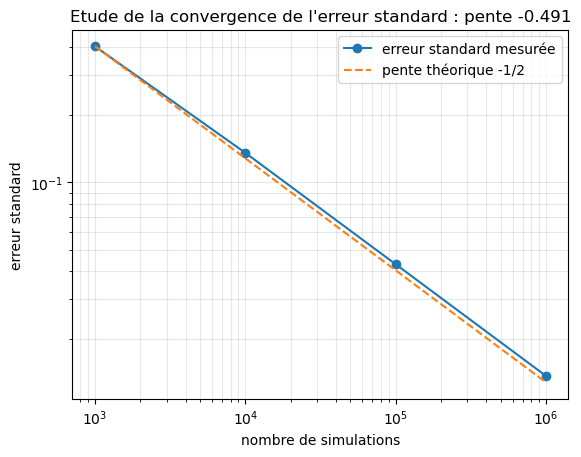

In [12]:
ref = data["err_std"][0] * (data["tailles"] / data["tailles"][0])**(-0.5)
pente, ordonnee = np.polyfit(np.log(data["tailles"]), np.log(data["err_std"]), 1)

plt.loglog(data["tailles"], data["err_std"], marker="o", label="erreur standard mesurée")
plt.loglog(data["tailles"], ref, linestyle="--", label="pente théorique -1/2")
plt.xlabel("nombre de simulations")
plt.ylabel("erreur standard")
plt.legend()
plt.title(f"Etude de la convergence de l'erreur standard : pente {pente:.3f}")
plt.grid(True, which="both", alpha=0.3)
plt.show()

--> On observe bien que l'estimateur se comporte comme la théorie le prédit

### Analyse performance réduction de variance

In [13]:
def perf_var(S,K,r,q,sigma,T,kind="call",n_sims=100000,seed=None):
    moyenne_mc, erreur_mc = mc.prix_mc(S, K, r, q, sigma, T, kind=kind, n_sims=n_sims, seed=seed)
    moyenne_antithetique, erreur_antithetique = mc.prix_mc_antithetique(S, K, r, q, sigma, T, kind=kind,
                         n_sims=n_sims, seed=seed)
    moyenne_varcontrole, erreur_varcontrole = mc.prix_mc_variable_controle(S, K, r, q, sigma, T, kind=kind,
                              n_sims=n_sims, seed=seed)
    facteur_antithetique = (erreur_mc/erreur_antithetique)**2
    facteur_vc = (erreur_mc/erreur_varcontrole)**2
    S_T = mc.simuler_terminal(S, r, q, sigma, T, n_sims=n_sims, seed=seed)
    payoffs = mc._payoff(S_T,K,kind=kind)
    correlation = np.corrcoef(S_T,payoffs)[0,1]
    facteur_vc_theorique = 1/(1-correlation**2)
    etude_var = {"prix_simple":moyenne_mc,"prix_anti":moyenne_antithetique,"prix_vc":moyenne_varcontrole,
                         "erreur_mc":erreur_mc,"erreur_anti":erreur_antithetique,"erreur_vc":erreur_varcontrole
                         ,"facteur_anti":facteur_antithetique,"facteur_vc":facteur_vc,"corr":correlation,"facteur_vc_th":facteur_vc_theorique}
    return etude_var

In [14]:
for K in (50.,100.,150.):
    resultats = perf_var(100., K, 0.03, 0.01, 0.20, 1.0, seed=0)
    print(f"STRIKE {K}")
    print(f"le prix simple : {resultats["prix_simple"]: .4f}")
    print(f"le prix avec var réduite antithétique : {resultats["prix_anti"]: .4f}")
    print(f"le prix avec var réduite var controle : {resultats["prix_vc"]: .4f}")
    print(f"facteur réduction variance avec par variables antithétiques : {resultats["facteur_anti"]: .4f}")
    print(f"le facteur réduction variance avec variable de contrôle : {resultats["facteur_vc"]: .4f}")
    print(f"facteur de réduction varcontrole théorique (1/(1-corr**2)): {resultats["facteur_vc_th"]:.4f}")
    print(f"correlation : {resultats["corr"]:.6f}\n")


STRIKE 50.0
le prix simple :  50.4654
le prix avec var réduite antithétique :  50.4893
le prix avec var réduite var controle :  50.4834
facteur réduction variance avec par variables antithétiques :  24.8845
le facteur réduction variance avec variable de contrôle :  149463.2912
facteur de réduction varcontrole théorique (1/(1-corr**2)): 149463.2912
correlation : 0.999997

STRIKE 100.0
le prix simple :  8.8166
le prix avec var réduite antithétique :  8.8515
le prix avec var réduite var controle :  8.8277
facteur réduction variance avec par variables antithétiques :  1.7100
le facteur réduction variance avec variable de contrôle :  5.5037
facteur de réduction varcontrole théorique (1/(1-corr**2)): 5.5037
correlation : 0.904602

STRIKE 150.0
le prix simple :  0.2502
le prix avec var réduite antithétique :  0.2556
le prix avec var réduite var controle :  0.2510
facteur réduction variance avec par variables antithétiques :  0.9881
le facteur réduction variance avec variable de contrôle :  1.

- On observe que la correlation est bien de plus en plus grande au fur et à mesure qu'on est dans la monnaie
- On observe que la réduction de variance par `variable de controle` fonctionne surtout très bien quand l'option est deep-in-the-money (fonction presque linéaire de S_T) pusi descentquand l'option pert de la valeur (14, puis, 5,5, puis 1.15)
- Par la méthode des `variables antithétiques` : même tendance, deep-in-the-money Z et -Z se compose parfaitement, et quand on est out-of-the-money, l'antithétique peut faire même moins bien (0.98)
- le facteur de réduction par méthode de variable de contrôle est très précis, preque égal à son resulat théorique

### Analyse des Greeks via Monte-Carlo (et comparaison à Black-Scholes)

In [15]:
resultats = [
    ("delta",*mc.delta_mc(*params,h=h_spot,seed=graine),bs.delta(*params)),
    ("gamma",*mc.gamma_mc(*params,h=h_spot,seed=graine),bs.gamma(*params)),
    ("vega",*mc.vega_mc(*params,h=h_vol,seed=graine),bs.vega(*params)),
    ("rho",*mc.rho_mc(*params,h=h_taux,seed=graine),bs.rho(*params)),
    ("theta",*mc.theta_mc(*params,h=h_temps,seed=graine),bs.theta(*params))
]

df = pd.DataFrame(resultats,columns=["Greeks","Monte-Carlo","Std Error","Black-Scholes"])
df["Ecart (err std)"] = ((df["Monte-Carlo"]-df["Black-Scholes"]).abs()/df["Std Error"])
df.set_index("Greeks",inplace=True)
df.round(4)


,Monte-Carlo,Std Error,Black-Scholes,Ecart (err std)
Greeks,,,,
delta,0.5719,0.0018,0.5735,0.8613
gamma,0.0189,0.0003,0.0194,1.2713
vega,38.9665,0.2341,38.7152,1.0737
rho,48.3594,0.1532,48.5223,1.0628
theta,-0.0130,0.0001,-0.0130,0.2576


### Analyse de l'influance des tirages communs

On boucle sur 100 seed pour avoir un résultat exploitable

In [16]:
repetitions = 100
delta_commun, err_commun = mc.delta_mc(*params,kind="call",h=h_spot,seed=graine)
rapports = []
delta = []
errs_ind = []

for i in range(repetitions):
    delta_ind, err_ind = mc.delta_mc(*params,kind="call",h=h_spot,seed=graine,seed2=graine+1000*i)
    rapports.append(err_ind/err_commun)
    delta.append(delta_ind)
    errs_ind.append(err_ind)

rapports = np.asarray(rapports)
delta = np.asarray(delta)
errs_ind = np.asarray(errs_ind)
mean_errs_ind = np.mean(errs_ind)
delta_mean = np.mean(delta)
ecart_type = np.mean(rapports)
variance = ecart_type**2
dispertion = np.std(rapports)

tirages = [
    ("delta_commun",delta_commun,err_commun,bs.delta(*params)),
    ("delta_independant_moyenné",delta_mean,mean_errs_ind,bs.delta(*params)),
]
df = pd.DataFrame(tirages,columns=["Greeks","Monte-Carlo","Std Error","Black-Scholes"])
df["Ecart (err std)"] = ((df["Monte-Carlo"]-df["Black-Scholes"]).abs()/df["Std Error"])
df.set_index("Greeks",inplace=True)
display(df.round(4))
print (f"facteur d'écart type : {ecart_type:.1f} +/- {dispertion:.1f}(dispertion) et facteur sur variance : {variance:.1f}")
print (f"Il faudrait environ {variance:.1f} fois plus de simulation avec des tirages indépendants que avec des tirages communs")

,Monte-Carlo,Std Error,Black-Scholes,Ecart (err std)
Greeks,,,,
delta_commun,0.5719,0.0018,0.5735,0.8613
delta_independant_moyenné,0.5674,0.0303,0.5735,0.2007


facteur d'écart type : 16.6 +/- 1.6(dispertion) et facteur sur variance : 274.4
Il faudrait environ 274.4 fois plus de simulation avec des tirages indépendants que avec des tirages communs


--> l'erreur standard avec des tirages indépendant exploxe (facteur 274) et réduit la précision du Monte-Carlo, comme prévu

--> l'écart type "plus petit" trouvée avec des tirages indépendant n'est pas significatif, et vient de l'imprécision trouvée sur l'écart type

### Figure

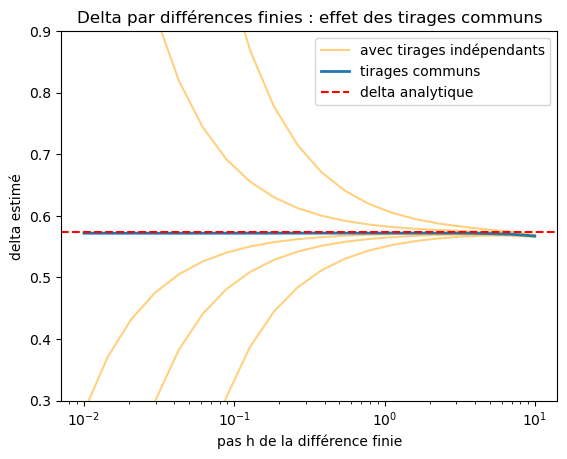

In [17]:
h_valeurs = np.logspace(-2, 1, 20)
graine = 0
graines2 = [1, 2, 3, 4, 5]
deltas_com = []

#tirages communs même graine
for h in h_valeurs:
    d, _ = mc.delta_mc(*params, kind="call", h=h, seed=graine)
    deltas_com.append(d)
deltas_com = np.asarray(deltas_com)
plt.figure()

#tirages indépendants (graines différentes)
for i, g2 in enumerate(graines2):
    deltas_ind = []
    for h in h_valeurs:
        delta_ind,err_ind = mc.delta_mc(*params,kind="call",h=h,seed=graine,seed2=g2)
        deltas_ind.append(delta_ind)
    deltas_ind = np.asarray(deltas_ind)
    plt.semilogx(h_valeurs,deltas_ind,label="avec tirages indépendants" if i==0 else None,color="orange",alpha=0.5)


plt.semilogx(h_valeurs, deltas_com, color="tab:blue", linewidth=2,label="tirages communs")

plt.axhline(bs.delta(*params), color="red", linestyle="--",label="delta analytique")
plt.ylim(0.3,0.9)
plt.xlabel("pas h de la différence finie")
plt.ylabel("delta estimé")
plt.title("Delta par différences finies : effet des tirages communs")
plt.legend()
plt.show()


--> sans tirages communs, réduire le pas h dégrade le résultat du delta estimé au lieu de l'améliorer.

--> C'est encore plus le cas pour des Greeks du second de gré type Gamma

### Test de l'équation de Black-Scholes

Testons la validité de $$\theta+(r-q).S.\delta+\frac{1}{2}.\sigma^2.S^2.\gamma = r.V$$

On fait avec la moyenne sur 20 graines pour avoir des résultats exploitables

In [18]:
graines = list(range(20))
h_spot = 1.0
h_temps = 0.01
params = (100., 100., 0.03, 0.01, 0.20, 1.0)
S,K,r,q,sigma,T = params

gauche_delta = []
gauche_gamma = []
gauche_theta = []
droite_list = []
ecarts = []
prix = []
for g in graines:
    delta,_ = mc.delta_mc(S, K, r, q, sigma, T,h_spot, kind="call", n_sims=100_000, seed=g)
    gamma,_ = mc.gamma_mc(S, K, r, q, sigma, T,h_spot, kind="call", n_sims=100_000, seed=g)
    theta,_ = mc.theta_mc(S, K, r, q, sigma, T,h_temps, kind="call", n_sims=100_000, seed=g)
    theta_year = theta*bs.DAYS_PER_YEAR
    V,_ = mc.prix_mc(S, K, r, q, sigma, T, kind="call", n_sims=100_000, seed=g)
    prix.append(V)
    droite = r*V
    droite_list.append(droite)
    gauche_theta.append(theta_year)
    gauche_delta.append((r-q)*S*delta)
    gauche_gamma.append((1/2)*(sigma**2)*(S**2)*gamma)
    ecart = theta_year + (r-q)*S*delta + (1/2)*(sigma**2)*(S**2)*gamma - r*V
    ecarts.append(ecart)
    
ecarts = np.asarray(ecarts)
moyenne_ecart = np.mean(ecarts)
ecart_type = np.std(ecarts)
erreur_std = ecart_type/np.sqrt(len(ecarts))
rapport = moyenne_ecart/erreur_std

m_gauche_delta = np.mean(np.asarray(gauche_delta))
m_gauche_gamma = np.mean(np.asarray(gauche_gamma))
m_gauche_theta = np.mean(np.asarray(gauche_theta))
gauche = m_gauche_theta + m_gauche_delta + m_gauche_gamma
m_droite = np.mean(np.asarray(droite_list))
V_mc = np.mean(np.asarray(prix))

resultats = {"g_theta":m_gauche_theta,"g_delta":m_gauche_delta,"g_gamma":m_gauche_gamma,"gauche":gauche,"droite":m_droite,"moyenne ecart":moyenne_ecart,"prix_MC":V_mc,"ecart type":ecart_type,"erreur std":erreur_std,"rapport":rapport}
df = pd.DataFrame(resultats,["resultats MC"])
display(df)


#Avec Black-Scholes
delta_bs = bs.delta(S, K, r, q, sigma, T, kind="call")
gamma_bs = bs.gamma(S, K, r, q, sigma, T, kind="call")
theta_bs = bs.theta(S, K, r, q, sigma, T, kind="call")
theta_year_bs = theta_bs*bs.DAYS_PER_YEAR

gauche1 = theta_year_bs
gauche2 = (r-q)*S*delta_bs
gauche3 = (1/2)*(sigma**2)*(S**2)*gamma_bs
gauche = gauche1+gauche2+gauche3
V_bs = bs.price(S, K, r, q, sigma, T, kind="call")
droite = r*V_bs
diff = gauche-droite

resultats = {"g_theta":gauche1,"g_delta":gauche2,"g_gamma":gauche3,"gauche":gauche,"droite":droite,"ecart":diff,"prix_BS":V_bs}
df2 = pd.DataFrame(resultats,["resultats BS"])
display(df2)


,g_theta,g_delta,g_gamma,gauche,droite,moyenne ecart,prix_MC,ecart type,erreur std,rapport
resultats MC,-4.752402,1.146937,3.867799,0.262334,0.264776,-0.002442,8.825865,0.072719,0.01626,-0.150185


,g_theta,g_delta,g_gamma,gauche,droite,ecart,prix_BS
resultats BS,-4.75369,1.146992,3.871518,0.26482,0.26482,7.771561e-16,8.827321


--> On observe que l'équation est bien vérifiée par rapport à Black_Scholes. On observe que le gamma est l'élement le moins précis avec MC, ce qui est cohérent car c'est une dérivée seconde. 

--> On observe que le rapport (de la moyenne des ecarts / erreur standard) est de 0.15 en valeur absolue (1/6 erreur standard) donc inférieur à 2 erreurs standard